In [1]:
# ============================================================
# CELL 01 - IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 02 - SET FILE PATHS
# ============================================================

# Automatically get the current working directory
current_dir = Path(os.getcwd())

# Define file paths
train_file = current_dir / "input" / "train.csv"
test_file = current_dir / "input" / "test.csv"
sample_sub_file = current_dir / "input" / "sample_submission.csv"

# Check if paths exist
print("Current directory:")
print(current_dir)

print("\nChecking files...")

if train_file.exists():
    print("✓ train.csv found")
else:
    print("✗ train.csv NOT found")

if test_file.exists():
    print("✓ test.csv found")
else:
    print("✗ test.csv NOT found")

if sample_sub_file.exists():
    print("✓ sample_submission.csv found")
else:
    print("✗ sample_submission.csv NOT found")

Current directory:
d:\Personal\Study\Projects\Competition

Checking files...
✓ train.csv found
✓ test.csv found
✓ sample_submission.csv found


In [3]:
# ============================================================
# CELL 03 - LOAD DATA
# ============================================================

train = pd.read_csv(train_file)
test = pd.read_csv(test_file)
sample_sub = pd.read_csv(sample_sub_file)

print("Data loaded successfully.")

Data loaded successfully.


In [4]:
# ============================================================
# CELL 04 - CHECK SHAPES
# ============================================================

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Sample submission shape: {sample_sub.shape}")

Train shape: (171202, 34)
Test shape:  (61500, 33)
Sample submission shape: (61500, 2)


In [5]:
# ============================================================
# CELL 05 - TRAIN DATA
# ============================================================

train.head(5)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET
0,0,Cash loans,F,0,112500.0,755190.0,36328.5,675000.0,Working,Higher education,...,School,NaN,0.372591,NaN,-292.0,NaN,NaN,NaN,NaN,0
1,1,Cash loans,F,0,225000.0,585000.0,16893.0,585000.0,Pensioner,Secondary / secondary special,...,XNA,NaN,0.449567,0.553165,-617.0,0.0,0.0,0.0,1.0,0
2,2,Cash loans,F,0,54000.0,334152.0,18256.5,270000.0,State servant,Secondary / secondary special,...,Postal,NaN,0.569503,NaN,-542.0,NaN,NaN,NaN,NaN,0
3,3,Cash loans,F,0,67500.0,152820.0,8901.0,135000.0,Pensioner,Lower secondary,...,XNA,NaN,0.105235,0.767523,0.0,0.0,0.0,0.0,0.0,0
4,4,Cash loans,M,0,157500.0,271066.5,21546.0,234000.0,Commercial associate,Secondary / secondary special,...,Business Entity Type 3,0.342344,0.202490,0.669057,-1243.0,0.0,0.0,0.0,4.0,1


In [6]:
# ============================================================
# CELL 06 - TEST DATA
# ============================================================

test.head(5)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,REGION_RATING_CLIENT,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,171202,Cash loans,F,1,144000.0,961146.0,28233.0,688500.0,Working,Higher education,...,2,Kindergarten,NaN,0.720416,NaN,-1.0,NaN,NaN,NaN,NaN
1,171203,Cash loans,F,0,103500.0,296280.0,16069.5,225000.0,Working,Secondary / secondary special,...,2,School,NaN,0.287306,NaN,-212.0,NaN,NaN,NaN,NaN
2,171204,Cash loans,F,1,180000.0,183694.5,11236.5,139500.0,Commercial associate,Secondary / secondary special,...,3,Trade: type 7,NaN,0.352456,0.389339,-428.0,0.0,1.0,1.0,1.0
3,171205,Revolving loans,F,2,225000.0,450000.0,22500.0,450000.0,Working,Higher education,...,2,Business Entity Type 3,NaN,0.470384,0.217629,-442.0,0.0,0.0,0.0,3.0
4,171206,Cash loans,F,2,144000.0,545040.0,26640.0,450000.0,Working,Higher education,...,3,Business Entity Type 3,0.269931,0.373133,NaN,-1333.0,0.0,0.0,0.0,3.0


In [7]:
# ============================================================
# CELL 07 - DATA INFORMATION
# ============================================================

print("TRAIN INFORMATION")
print("=" * 60)

train.info()

TRAIN INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 171202 entries, 0 to 171201
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   SK_ID_CURR                  171202 non-null  int64  
 1   NAME_CONTRACT_TYPE          171202 non-null  str    
 2   CODE_GENDER                 171202 non-null  str    
 3   CNT_CHILDREN                171202 non-null  int64  
 4   AMT_INCOME_TOTAL            171202 non-null  float64
 5   AMT_CREDIT                  171202 non-null  float64
 6   AMT_ANNUITY                 171202 non-null  float64
 7   AMT_GOODS_PRICE             171202 non-null  float64
 8   NAME_INCOME_TYPE            171202 non-null  str    
 9   NAME_EDUCATION_TYPE         171202 non-null  str    
 10  NAME_FAMILY_STATUS          171202 non-null  str    
 11  NAME_HOUSING_TYPE           171202 non-null  str    
 12  REGION_POPULATION_RELATIVE  171202 non-null  float64
 13  DAYS_BI

In [8]:
# ============================================================
# CELL 08 - TARGET DISTRIBUTION
# ============================================================

print(train["TARGET"].value_counts())
print("\nTarget percentages:")
print(train["TARGET"].value_counts(normalize=True) * 100)

TARGET
0    157381
1     13821
Name: count, dtype: int64

Target percentages:
TARGET
0    91.92708
1     8.07292
Name: proportion, dtype: float64


In [9]:
# ============================================================
# CELL 09 - ORIGINAL FEATURES
# ============================================================

use_features = [
    "NAME_CONTRACT_TYPE",
    "AMT_INCOME_TOTAL",
    "EXT_SOURCE_2",
    "OWN_CAR_AGE",
    "ORGANIZATION_TYPE"
]

target = train["TARGET"].copy()

train = train[use_features].copy()
train["TARGET"] = target

test = test[use_features].copy()

print("Original features:")
print(use_features)

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

Original features:
['NAME_CONTRACT_TYPE', 'AMT_INCOME_TOTAL', 'EXT_SOURCE_2', 'OWN_CAR_AGE', 'ORGANIZATION_TYPE']

Train shape: (171202, 6)
Test shape: (61500, 5)


In [10]:
# ============================================================
# CELL 10 - MISSING VALUES
# ============================================================

print("Missing values in train:")
print(train.isnull().sum())

print("\nMissing values in test:")
print(test.isnull().sum())

Missing values in train:
NAME_CONTRACT_TYPE         0
AMT_INCOME_TOTAL           0
EXT_SOURCE_2             369
OWN_CAR_AGE           112992
ORGANIZATION_TYPE          0
TARGET                     0
dtype: int64

Missing values in test:
NAME_CONTRACT_TYPE        0
AMT_INCOME_TOTAL          0
EXT_SOURCE_2            130
OWN_CAR_AGE           40909
ORGANIZATION_TYPE         0
dtype: int64


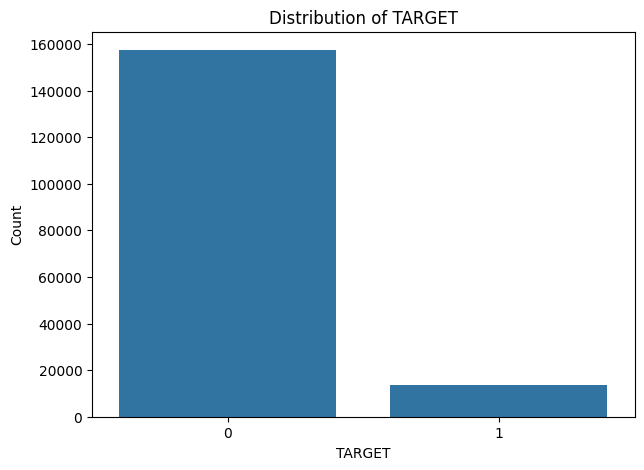

In [11]:
# ============================================================
# CELL 11 - TARGET VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=train,
    x="TARGET"
)

plt.title("Distribution of TARGET")
plt.xlabel("TARGET")
plt.ylabel("Count")

plt.show()

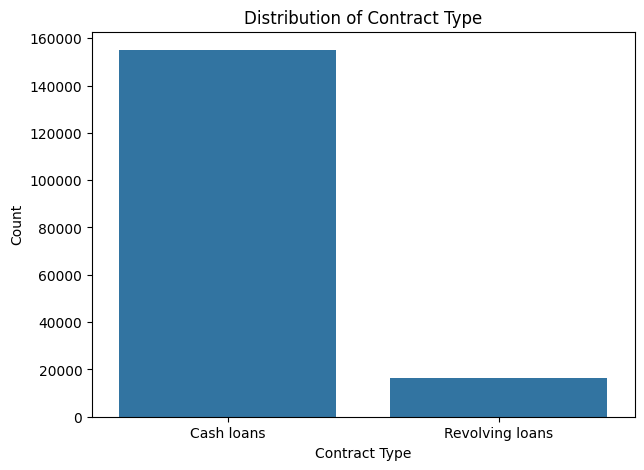

In [12]:
# ============================================================
# CELL 12 - CONTRACT TYPE
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=train,
    x="NAME_CONTRACT_TYPE"
)

plt.title("Distribution of Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")

plt.show()

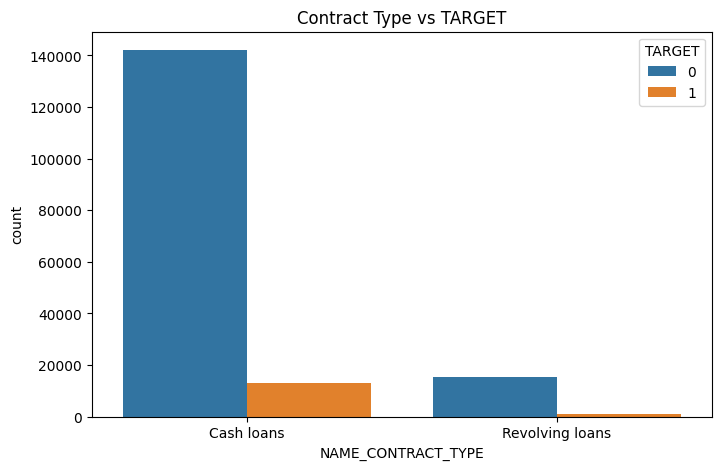

In [13]:
# ============================================================
# CELL 13 - CONTRACT TYPE VS TARGET
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=train,
    x="NAME_CONTRACT_TYPE",
    hue="TARGET"
)

plt.title("Contract Type vs TARGET")
plt.show()

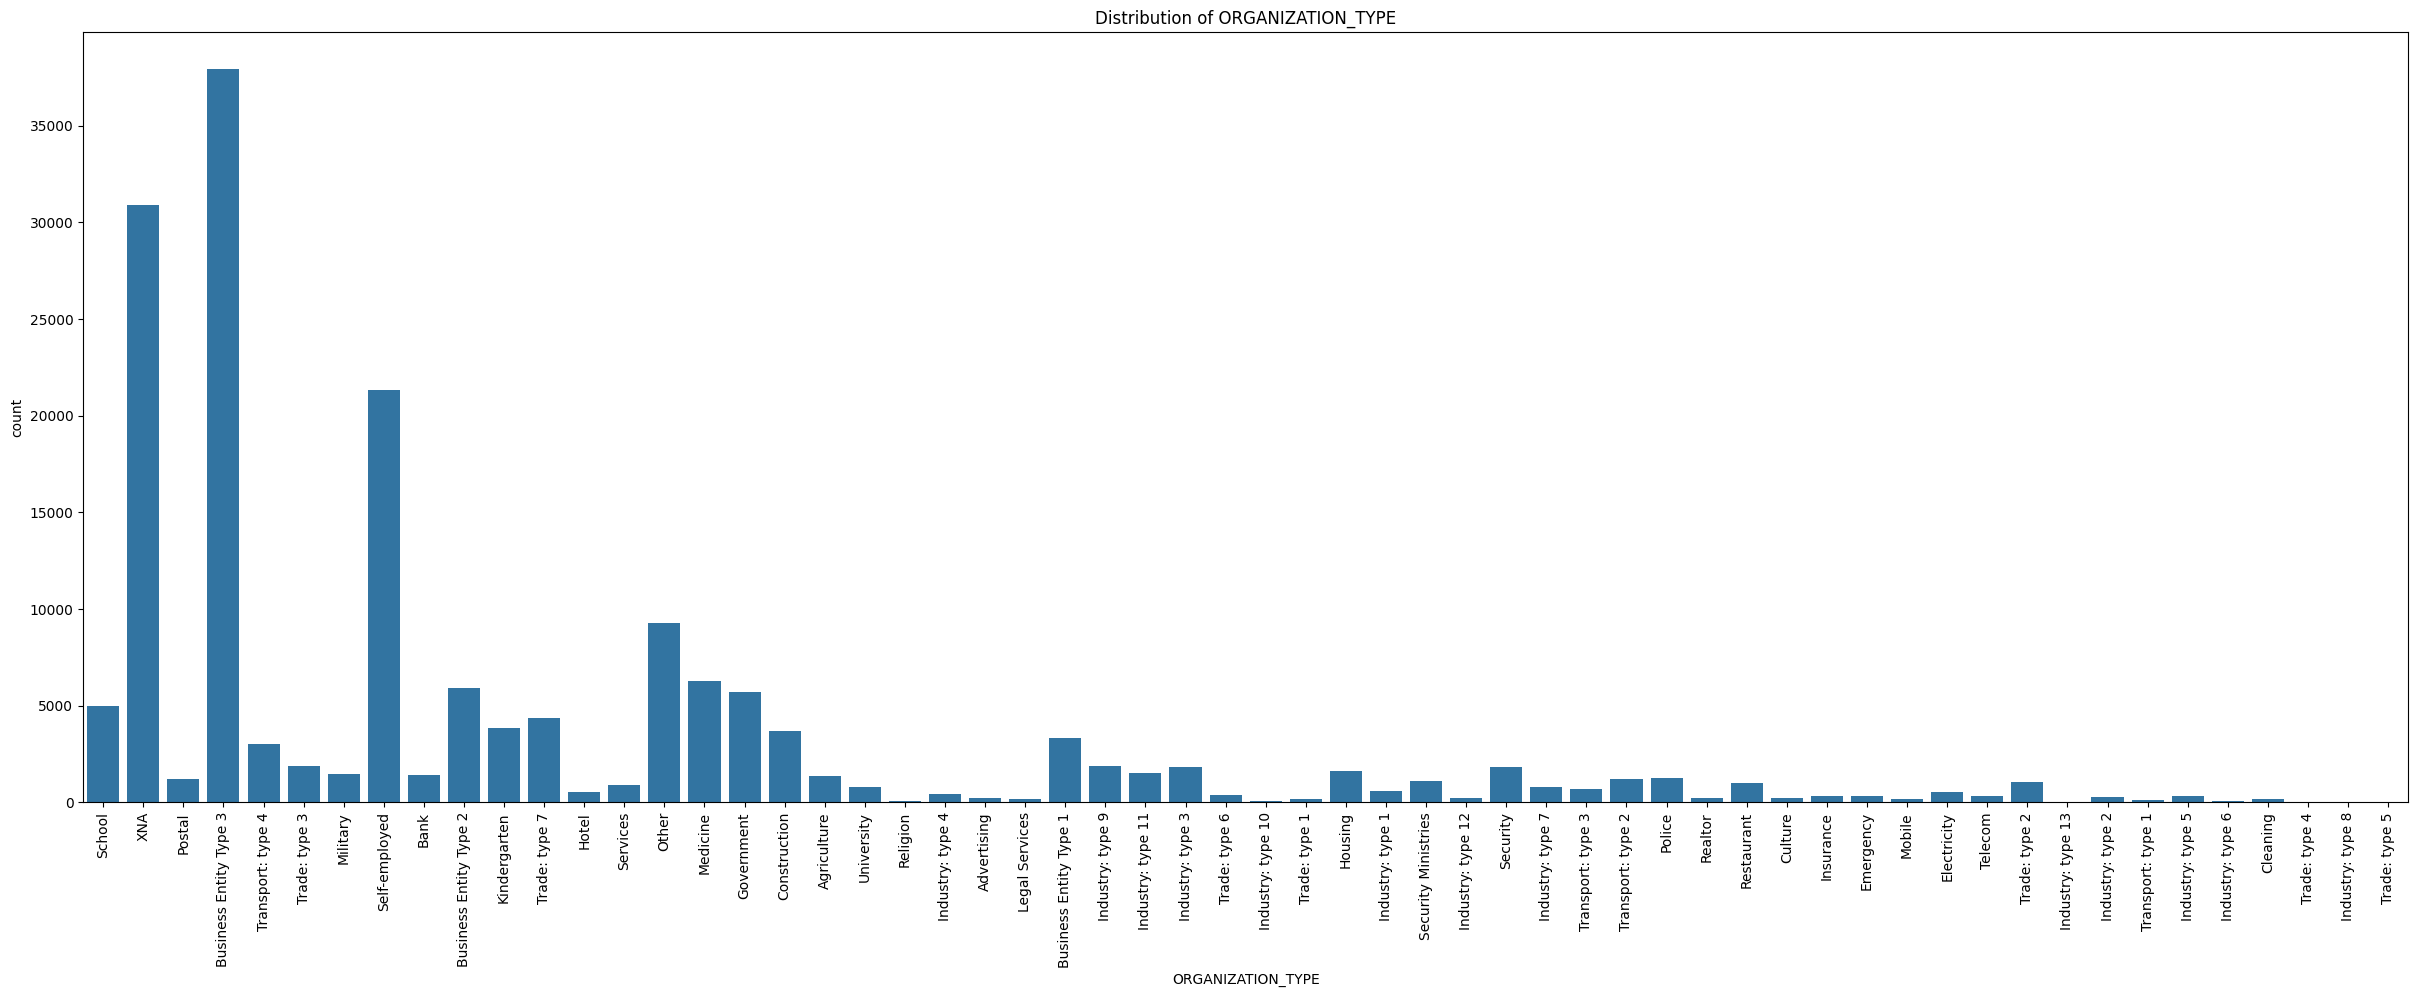

In [14]:
# ============================================================
# CELL 14 - ORGANIZATION TYPE
# ============================================================

plt.figure(figsize=(30, 10))

sns.countplot(
    data=train,
    x="ORGANIZATION_TYPE"
)

plt.title("Distribution of ORGANIZATION_TYPE")

plt.xticks(
    rotation=90
)

plt.show()

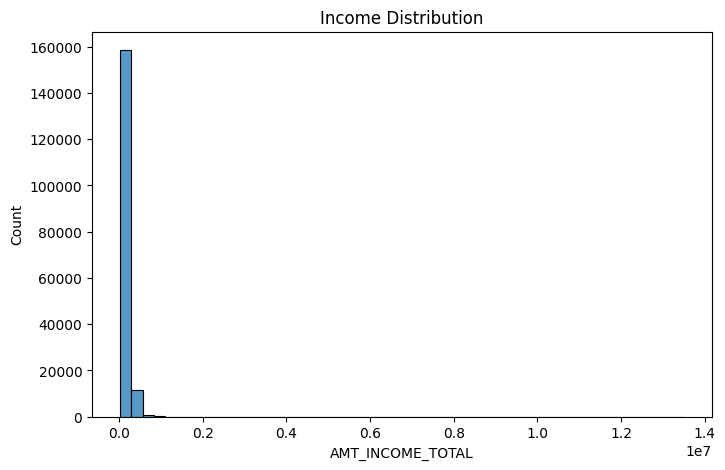

In [15]:
# ============================================================
# CELL 15 - INCOME DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=train,
    x="AMT_INCOME_TOTAL",
    bins=50
)

plt.title("Income Distribution")
plt.show()

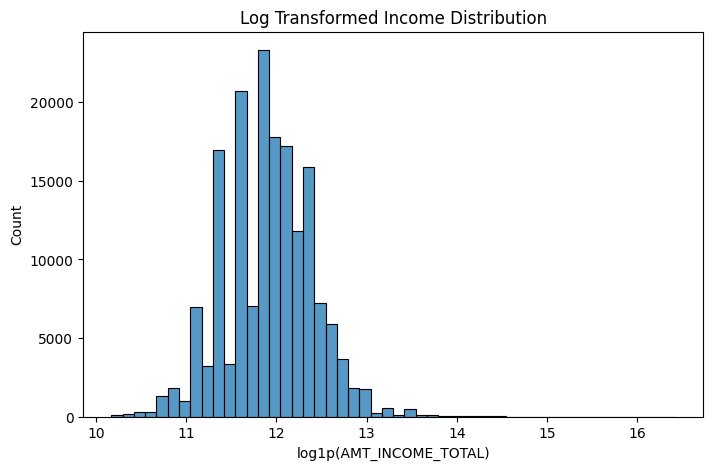

In [16]:
# ============================================================
# CELL 16 - LOG INCOME DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    np.log1p(train["AMT_INCOME_TOTAL"]),
    bins=50
)

plt.title("Log Transformed Income Distribution")
plt.xlabel("log1p(AMT_INCOME_TOTAL)")

plt.show()

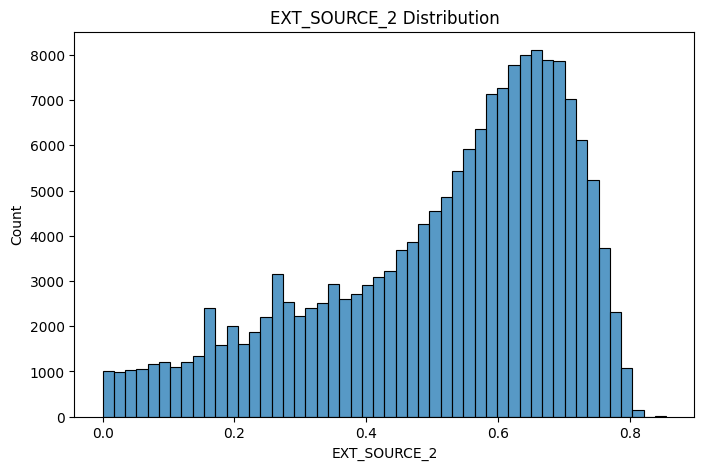

In [17]:
# ============================================================
# CELL 17 - EXT_SOURCE_2 DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=train,
    x="EXT_SOURCE_2",
    bins=50
)

plt.title("EXT_SOURCE_2 Distribution")

plt.show()

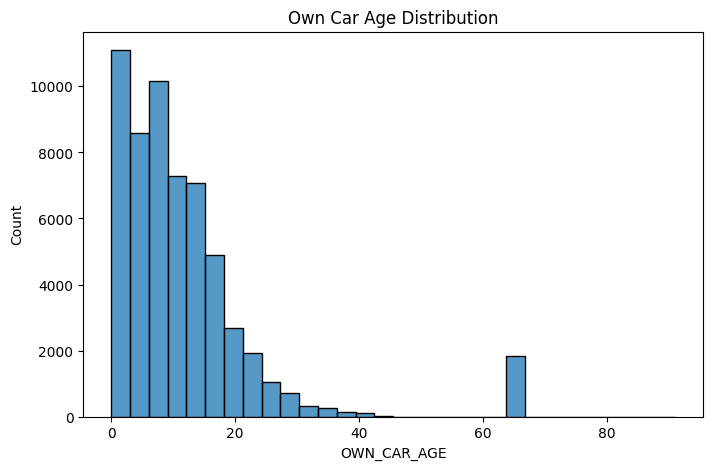

In [18]:
# ============================================================
# CELL 18 - CAR AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=train,
    x="OWN_CAR_AGE",
    bins=30
)

plt.title("Own Car Age Distribution")

plt.show()

NAME_CONTRACT_TYPE
Cash loans         0.083368
Revolving loans    0.055508
Name: TARGET, dtype: float64


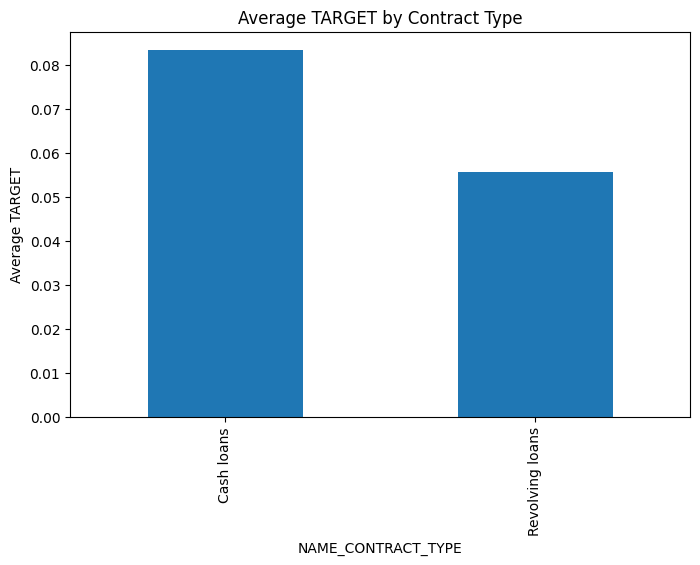

In [19]:
# ============================================================
# CELL 19 - TARGET RATE BY CONTRACT TYPE
# ============================================================

contract_target = (
    train.groupby("NAME_CONTRACT_TYPE")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

print(contract_target)

contract_target.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average TARGET by Contract Type")
plt.ylabel("Average TARGET")

plt.show()

In [20]:
# ============================================================
# CELL 20 - TARGET RATE BY ORGANIZATION
# ============================================================

organization_target = (
    train.groupby("ORGANIZATION_TYPE")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

print(organization_target.head(20))

ORGANIZATION_TYPE
Transport: type 3         0.161631
Industry: type 8          0.125000
Realtor                   0.123967
Restaurant                0.117878
Cleaning                  0.109589
Construction              0.108649
Industry: type 3          0.105292
Security                  0.104626
Agriculture               0.102392
Self-employed             0.100984
Trade: type 3             0.100796
Industry: type 1          0.096121
Trade: type 7             0.095249
Transport: type 4         0.094874
Business Entity Type 3    0.093614
Business Entity Type 2    0.087456
Industry: type 11         0.087043
Mobile                    0.085714
Business Entity Type 1    0.084889
Housing                   0.084315
Name: TARGET, dtype: float64


In [21]:
# ============================================================
# CELL 21 - COPY DATA
# ============================================================

X_raw = train.drop("TARGET", axis=1).copy()
y = train["TARGET"].copy()

X_test_raw = test.copy()

print("X_raw shape:", X_raw.shape)
print("X_test_raw shape:", X_test_raw.shape)

X_raw shape: (171202, 5)
X_test_raw shape: (61500, 5)


In [22]:
# ============================================================
# CELL 22 - CONTRACT TYPE ENCODING
# ============================================================

contract_mapping = {
    "Cash loans": 0,
    "Revolving loans": 1
}

X_raw["NAME_CONTRACT_TYPE"] = (
    X_raw["NAME_CONTRACT_TYPE"]
    .map(contract_mapping)
)

X_test_raw["NAME_CONTRACT_TYPE"] = (
    X_test_raw["NAME_CONTRACT_TYPE"]
    .map(contract_mapping)
)

print(X_raw["NAME_CONTRACT_TYPE"].value_counts(dropna=False))

NAME_CONTRACT_TYPE
0    154988
1     16214
Name: count, dtype: int64


In [23]:
# ============================================================
# CELL 23 - ORGANIZATION FREQUENCY ENCODING
# ============================================================

organization_frequency = (
    X_raw["ORGANIZATION_TYPE"]
    .value_counts()
)

X_raw["ORGANIZATION_TYPE_FREQ"] = (
    X_raw["ORGANIZATION_TYPE"]
    .map(organization_frequency)
)

X_test_raw["ORGANIZATION_TYPE_FREQ"] = (
    X_test_raw["ORGANIZATION_TYPE"]
    .map(organization_frequency)
    .fillna(0)
)

print(
    X_raw[
        ["ORGANIZATION_TYPE", "ORGANIZATION_TYPE_FREQ"]
    ].head()
)

        ORGANIZATION_TYPE  ORGANIZATION_TYPE_FREQ
0                  School                    4991
1                     XNA                   30898
2                  Postal                    1185
3                     XNA                   30898
4  Business Entity Type 3                   37943


In [24]:
# ============================================================
# CELL 24 - ORGANIZATION ONE-HOT ENCODING
# ============================================================

organization_ohe_train = pd.get_dummies(
    X_raw["ORGANIZATION_TYPE"],
    prefix="ORG",
    dummy_na=True
)

organization_ohe_test = pd.get_dummies(
    X_test_raw["ORGANIZATION_TYPE"],
    prefix="ORG",
    dummy_na=True
)

organization_ohe_train, organization_ohe_test = (
    organization_ohe_train.align(
        organization_ohe_test,
        join="outer",
        axis=1,
        fill_value=0
    )
)

print(
    "Organization OHE shape:",
    organization_ohe_train.shape
)

Organization OHE shape: (171202, 59)


In [25]:
# ============================================================
# CELL 25 - EXT_SOURCE_2 IMPUTATION
# ============================================================

ext_source_mean = X_raw["EXT_SOURCE_2"].mean()

X_raw["EXT_SOURCE_2_MISSING"] = (
    X_raw["EXT_SOURCE_2"].isnull().astype(int)
)

X_test_raw["EXT_SOURCE_2_MISSING"] = (
    X_test_raw["EXT_SOURCE_2"].isnull().astype(int)
)

X_raw["EXT_SOURCE_2"] = (
    X_raw["EXT_SOURCE_2"]
    .fillna(ext_source_mean)
)

X_test_raw["EXT_SOURCE_2"] = (
    X_test_raw["EXT_SOURCE_2"]
    .fillna(ext_source_mean)
)

print("EXT_SOURCE_2 missing values:")
print(X_raw["EXT_SOURCE_2"].isnull().sum())

EXT_SOURCE_2 missing values:
0


In [26]:
# ============================================================
# CELL 26 - INCOME IMPUTATION
# ============================================================

income_median = X_raw["AMT_INCOME_TOTAL"].median()

X_raw["AMT_INCOME_TOTAL_MISSING"] = (
    X_raw["AMT_INCOME_TOTAL"].isnull().astype(int)
)

X_test_raw["AMT_INCOME_TOTAL_MISSING"] = (
    X_test_raw["AMT_INCOME_TOTAL"].isnull().astype(int)
)

X_raw["AMT_INCOME_TOTAL"] = (
    X_raw["AMT_INCOME_TOTAL"]
    .fillna(income_median)
)

X_test_raw["AMT_INCOME_TOTAL"] = (
    X_test_raw["AMT_INCOME_TOTAL"]
    .fillna(income_median)
)

In [27]:
# ============================================================
# CELL 27 - CAR AGE CLEANING
# ============================================================

X_raw["OWN_CAR_AGE_MISSING"] = (
    X_raw["OWN_CAR_AGE"].isnull().astype(int)
)

X_test_raw["OWN_CAR_AGE_MISSING"] = (
    X_test_raw["OWN_CAR_AGE"].isnull().astype(int)
)

X_raw.loc[
    X_raw["OWN_CAR_AGE"] >= 60,
    "OWN_CAR_AGE"
] = np.nan

X_test_raw.loc[
    X_test_raw["OWN_CAR_AGE"] >= 60,
    "OWN_CAR_AGE"
] = np.nan

# Convert to groups exactly like your original code
X_raw["OWN_CAR_AGE"] = (
    X_raw["OWN_CAR_AGE"] // 10
)

X_test_raw["OWN_CAR_AGE"] = (
    X_test_raw["OWN_CAR_AGE"] // 10
)

print(
    X_raw["OWN_CAR_AGE"].value_counts(
        dropna=False
    ).sort_index()
)

OWN_CAR_AGE
0.0     29832
1.0     20291
2.0      5166
3.0       936
4.0       152
5.0         7
NaN    114818
Name: count, dtype: int64


In [28]:
# ============================================================
# CELL 28 - FEATURE ENGINEERING
# ============================================================

# -----------------------------
# 1. Log income
# -----------------------------

X_raw["INCOME_LOG"] = np.log1p(
    X_raw["AMT_INCOME_TOTAL"]
)

X_test_raw["INCOME_LOG"] = np.log1p(
    X_test_raw["AMT_INCOME_TOTAL"]
)


# -----------------------------
# 2. Income squared
# -----------------------------

X_raw["INCOME_SQ"] = (
    X_raw["AMT_INCOME_TOTAL"] ** 2
)

X_test_raw["INCOME_SQ"] = (
    X_test_raw["AMT_INCOME_TOTAL"] ** 2
)


# -----------------------------
# 3. EXT_SOURCE squared
# -----------------------------

X_raw["EXT_SOURCE_2_SQ"] = (
    X_raw["EXT_SOURCE_2"] ** 2
)

X_test_raw["EXT_SOURCE_2_SQ"] = (
    X_test_raw["EXT_SOURCE_2"] ** 2
)


# -----------------------------
# 4. Income × EXT_SOURCE
# -----------------------------

X_raw["INCOME_EXT_SOURCE"] = (
    X_raw["AMT_INCOME_TOTAL"]
    * X_raw["EXT_SOURCE_2"]
)

X_test_raw["INCOME_EXT_SOURCE"] = (
    X_test_raw["AMT_INCOME_TOTAL"]
    * X_test_raw["EXT_SOURCE_2"]
)


# -----------------------------
# 5. Income / EXT_SOURCE
# -----------------------------

X_raw["INCOME_PER_EXT"] = (
    X_raw["AMT_INCOME_TOTAL"]
    / (X_raw["EXT_SOURCE_2"] + 1e-6)
)

X_test_raw["INCOME_PER_EXT"] = (
    X_test_raw["AMT_INCOME_TOTAL"]
    / (X_test_raw["EXT_SOURCE_2"] + 1e-6)
)


# -----------------------------
# 6. Car age × EXT_SOURCE
# -----------------------------

X_raw["CAR_AGE_EXT"] = (
    X_raw["OWN_CAR_AGE"].fillna(-1)
    * X_raw["EXT_SOURCE_2"]
)

X_test_raw["CAR_AGE_EXT"] = (
    X_test_raw["OWN_CAR_AGE"].fillna(-1)
    * X_test_raw["EXT_SOURCE_2"]
)


# -----------------------------
# 7. Contract × EXT_SOURCE
# -----------------------------

X_raw["CONTRACT_EXT"] = (
    X_raw["NAME_CONTRACT_TYPE"]
    * X_raw["EXT_SOURCE_2"]
)

X_test_raw["CONTRACT_EXT"] = (
    X_test_raw["NAME_CONTRACT_TYPE"]
    * X_test_raw["EXT_SOURCE_2"]
)


# -----------------------------
# 8. Contract × Income
# -----------------------------

X_raw["CONTRACT_INCOME"] = (
    X_raw["NAME_CONTRACT_TYPE"]
    * X_raw["AMT_INCOME_TOTAL"]
)

X_test_raw["CONTRACT_INCOME"] = (
    X_test_raw["NAME_CONTRACT_TYPE"]
    * X_test_raw["AMT_INCOME_TOTAL"]
)


print("Feature engineering completed.")

Feature engineering completed.


In [29]:
# ============================================================
# CELL 29 - CAR AGE ONE-HOT ENCODING
# ============================================================

train_car_age_ohe = pd.get_dummies(
    X_raw["OWN_CAR_AGE"],
    prefix="OWN_CAR_AGE",
    dummy_na=True
)

test_car_age_ohe = pd.get_dummies(
    X_test_raw["OWN_CAR_AGE"],
    prefix="OWN_CAR_AGE",
    dummy_na=True
)

train_car_age_ohe, test_car_age_ohe = (
    train_car_age_ohe.align(
        test_car_age_ohe,
        join="outer",
        axis=1,
        fill_value=0
    )
)

print(train_car_age_ohe.head())

   OWN_CAR_AGE_0.0  OWN_CAR_AGE_1.0  OWN_CAR_AGE_2.0  OWN_CAR_AGE_3.0  \
0            False            False            False            False   
1            False            False            False            False   
2            False            False            False            False   
3            False            False            False            False   
4            False            False            False            False   

   OWN_CAR_AGE_4.0  OWN_CAR_AGE_5.0  OWN_CAR_AGE_nan  
0            False            False             True  
1            False            False             True  
2            False            False             True  
3            False            False             True  
4            False            False             True  


In [30]:
# ============================================================
# CELL 30 - COMBINE ALL FEATURES
# ============================================================

# Drop original categorical organization column
X_raw = X_raw.drop(
    "ORGANIZATION_TYPE",
    axis=1
)

X_test_raw = X_test_raw.drop(
    "ORGANIZATION_TYPE",
    axis=1
)

# Add organization one-hot features
X_raw = pd.concat(
    [
        X_raw,
        organization_ohe_train
    ],
    axis=1
)

X_test_raw = pd.concat(
    [
        X_test_raw,
        organization_ohe_test
    ],
    axis=1
)

# Add car age one-hot features
X_raw = pd.concat(
    [
        X_raw,
        train_car_age_ohe
    ],
    axis=1
)

X_test_raw = pd.concat(
    [
        X_test_raw,
        test_car_age_ohe
    ],
    axis=1
)

# Remove original grouped car age
X_raw = X_raw.drop(
    "OWN_CAR_AGE",
    axis=1
)

X_test_raw = X_test_raw.drop(
    "OWN_CAR_AGE",
    axis=1
)

print("Final X shape:", X_raw.shape)
print("Final test shape:", X_test_raw.shape)

Final X shape: (171202, 81)
Final test shape: (61500, 81)


In [31]:
# ============================================================
# CELL 31 - NUMERIC CONVERSION
# ============================================================

X = X_raw.copy()
X_test = X_test_raw.copy()

# Convert boolean columns to integer
bool_columns = X.select_dtypes(
    include=["bool"]
).columns

X[bool_columns] = X[bool_columns].astype(int)
X_test[bool_columns] = X_test[bool_columns].astype(int)

# Make sure train and test columns are identical
X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("Final training features:", X.shape)
print("Final testing features:", X_test.shape)

print("\nRemaining object columns:")
print(X.select_dtypes(include="object").columns.tolist())

Final training features: (171202, 81)
Final testing features: (61500, 81)

Remaining object columns:
[]


In [32]:
# ============================================================
# CELL 32 - FINAL MISSING VALUE CHECK
# ============================================================

print("Missing values in X:")
print(X.isnull().sum().sort_values(ascending=False).head(20))

print("\nTotal missing values in X:", X.isnull().sum().sum())
print(
    "Total missing values in X_test:",
    X_test.isnull().sum().sum()
)

Missing values in X:
NAME_CONTRACT_TYPE         0
ORG_Industry: type 9       0
ORG_Telecom                0
ORG_Services               0
ORG_Self-employed          0
ORG_Security Ministries    0
ORG_Security               0
ORG_School                 0
ORG_Restaurant             0
ORG_Religion               0
ORG_Realtor                0
ORG_Postal                 0
ORG_Police                 0
ORG_Other                  0
ORG_Mobile                 0
ORG_Military               0
ORG_Medicine               0
ORG_Legal Services         0
ORG_Kindergarten           0
ORG_Trade: type 1          0
dtype: int64

Total missing values in X: 0
Total missing values in X_test: 0


In [33]:
# ============================================================
# CELL 33 - FINAL IMPUTATION
# ============================================================

for column in X.columns:

    if X[column].isnull().any():

        median_value = X[column].median()

        X[column] = X[column].fillna(
            median_value
        )

        X_test[column] = X_test[column].fillna(
            median_value
        )

print("Remaining train missing values:")
print(X.isnull().sum().sum())

print("Remaining test missing values:")
print(X_test.isnull().sum().sum())

Remaining train missing values:
0
Remaining test missing values:
0


In [34]:
# ============================================================
# CELL 34 - CORRELATION
# ============================================================

correlation_data = X.copy()

correlation_data["TARGET"] = y.values

correlations = (
    correlation_data.corr(numeric_only=True)["TARGET"]
    .sort_values()
)

print("Lowest correlations:")
print(correlations.head(10))

print("\nHighest correlations:")
print(correlations.tail(10))

Lowest correlations:
EXT_SOURCE_2         -0.162391
EXT_SOURCE_2_SQ      -0.151476
INCOME_EXT_SOURCE    -0.084498
ORG_XNA              -0.045626
CONTRACT_EXT         -0.041246
OWN_CAR_AGE_0.0      -0.035855
CONTRACT_INCOME      -0.032417
NAME_CONTRACT_TYPE   -0.029946
AMT_INCOME_TOTAL     -0.021638
INCOME_LOG           -0.018640
Name: TARGET, dtype: float64

Highest correlations:
ORG_Construction              0.015232
ORG_Transport: type 3         0.018503
OWN_CAR_AGE_MISSING           0.021647
OWN_CAR_AGE_nan               0.022530
ORG_Business Entity Type 3    0.025238
CAR_AGE_EXT                   0.026489
ORG_Self-employed             0.028057
TARGET                        1.000000
AMT_INCOME_TOTAL_MISSING           NaN
ORG_nan                            NaN
Name: TARGET, dtype: float64


In [35]:
# ============================================================
# CELL 35 - TRAIN VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=0
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (119841, 81)
X_valid: (51361, 81)
y_train: (119841,)
y_valid: (51361,)


In [36]:
# ============================================================
# CELL 36 - STANDARD SCALER
# ============================================================

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_std = sc.fit_transform(X_train)

X_valid_std = sc.transform(X_valid)

X_test_std = sc.transform(X_test)

print("X_train_std:", X_train_std.shape)
print("X_valid_std:", X_valid_std.shape)
print("X_test_std:", X_test_std.shape)

X_train_std: (119841, 81)
X_valid_std: (51361, 81)
X_test_std: (61500, 81)


In [37]:
# ============================================================
# CELL 37 - LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr = LogisticRegression(
    random_state=0,
    max_iter=1000
)

lr.fit(
    X_train_std,
    y_train
)

lr_train_pred = lr.predict_proba(
    X_train_std
)[:, 1]

lr_valid_pred = lr.predict_proba(
    X_valid_std
)[:, 1]

lr_train_score = roc_auc_score(
    y_train,
    lr_train_pred
)

lr_valid_score = roc_auc_score(
    y_valid,
    lr_valid_pred
)

print(
    f"Logistic Regression Train ROC-AUC: "
    f"{lr_train_score:.4f}"
)

print(
    f"Logistic Regression Valid ROC-AUC: "
    f"{lr_valid_score:.4f}"
)

Logistic Regression Train ROC-AUC: 0.6792
Logistic Regression Valid ROC-AUC: 0.6761


In [38]:
# ============================================================
# CELL 38 - RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=0,
    max_depth=10,
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(
    X_train,
    y_train
)

rf_train_pred = rf.predict_proba(
    X_train
)[:, 1]

rf_valid_pred = rf.predict_proba(
    X_valid
)[:, 1]

rf_train_score = roc_auc_score(
    y_train,
    rf_train_pred
)

rf_valid_score = roc_auc_score(
    y_valid,
    rf_valid_pred
)

print(
    f"Random Forest Train ROC-AUC: "
    f"{rf_train_score:.4f}"
)

print(
    f"Random Forest Valid ROC-AUC: "
    f"{rf_valid_score:.4f}"
)

Random Forest Train ROC-AUC: 0.7204
Random Forest Valid ROC-AUC: 0.6713


In [39]:
# ============================================================
# CELL 39 - ADABOOST
# ============================================================

from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=0
)

ada.fit(
    X_train,
    y_train
)

ada_train_pred = ada.predict_proba(
    X_train
)[:, 1]

ada_valid_pred = ada.predict_proba(
    X_valid
)[:, 1]

ada_train_score = roc_auc_score(
    y_train,
    ada_train_pred
)

ada_valid_score = roc_auc_score(
    y_valid,
    ada_valid_pred
)

print(
    f"AdaBoost Train ROC-AUC: "
    f"{ada_train_score:.4f}"
)

print(
    f"AdaBoost Valid ROC-AUC: "
    f"{ada_valid_score:.4f}"
)

AdaBoost Train ROC-AUC: 0.6660
AdaBoost Valid ROC-AUC: 0.6641


In [40]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [41]:
# ============================================================
# CELL 40 - XGBOOST
# ============================================================

try:

    from xgboost import XGBClassifier

    xgb = XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=0,
        n_jobs=-1
    )

    xgb.fit(
        X_train,
        y_train
    )

    xgb_train_pred = xgb.predict_proba(
        X_train
    )[:, 1]

    xgb_valid_pred = xgb.predict_proba(
        X_valid
    )[:, 1]

    xgb_train_score = roc_auc_score(
        y_train,
        xgb_train_pred
    )

    xgb_valid_score = roc_auc_score(
        y_valid,
        xgb_valid_pred
    )

    print(
        f"XGBoost Train ROC-AUC: "
        f"{xgb_train_score:.4f}"
    )

    print(
        f"XGBoost Valid ROC-AUC: "
        f"{xgb_valid_score:.4f}"
    )

except ImportError:

    print("XGBoost is not installed.")
    print("Run: pip install xgboost")

XGBoost Train ROC-AUC: 0.7174
XGBoost Valid ROC-AUC: 0.6709


In [42]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [43]:
# ============================================================
# CELL 41 - CATBOOST
# ============================================================

try:

    from catboost import CatBoostClassifier

    cat = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=0,
        verbose=False
    )

    cat.fit(
        X_train,
        y_train
    )

    cat_train_pred = cat.predict_proba(
        X_train
    )[:, 1]

    cat_valid_pred = cat.predict_proba(
        X_valid
    )[:, 1]

    cat_train_score = roc_auc_score(
        y_train,
        cat_train_pred
    )

    cat_valid_score = roc_auc_score(
        y_valid,
        cat_valid_pred
    )

    print(
        f"CatBoost Train ROC-AUC: "
        f"{cat_train_score:.4f}"
    )

    print(
        f"CatBoost Valid ROC-AUC: "
        f"{cat_valid_score:.4f}"
    )

except ImportError:

    print("CatBoost is not installed.")
    print("Run: pip install catboost")

CatBoost Train ROC-AUC: 0.6949
CatBoost Valid ROC-AUC: 0.6755


In [44]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [45]:
# ============================================================
# CELL 42 - LIGHTGBM
# ============================================================

try:

    from lightgbm import LGBMClassifier

    # --------------------------------------------------------
    # Clean feature names for LightGBM
    # --------------------------------------------------------

    X_train_lgb = X_train.copy()
    X_valid_lgb = X_valid.copy()
    X_test_lgb = X_test.copy()

    # Convert all column names to strings
    X_train_lgb.columns = X_train_lgb.columns.astype(str)
    X_valid_lgb.columns = X_valid_lgb.columns.astype(str)
    X_test_lgb.columns = X_test_lgb.columns.astype(str)

    # Remove special characters
    X_train_lgb.columns = (
        X_train_lgb.columns
        .str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
    )

    X_valid_lgb.columns = X_train_lgb.columns
    X_test_lgb.columns = X_train_lgb.columns

    # Make sure there are no duplicate feature names
    X_train_lgb = X_train_lgb.loc[
        :,
        ~X_train_lgb.columns.duplicated()
    ]

    X_valid_lgb = X_valid_lgb[
        X_train_lgb.columns
    ]

    X_test_lgb = X_test_lgb[
        X_train_lgb.columns
    ]

    # --------------------------------------------------------
    # LightGBM model
    # --------------------------------------------------------

    lgbm = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0,
        n_jobs=-1,
        verbosity=-1
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    lgbm.fit(
        X_train_lgb,
        y_train
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    lgbm_train_pred = lgbm.predict_proba(
        X_train_lgb
    )[:, 1]

    lgbm_valid_pred = lgbm.predict_proba(
        X_valid_lgb
    )[:, 1]

    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    lgbm_train_score = roc_auc_score(
        y_train,
        lgbm_train_pred
    )

    lgbm_valid_score = roc_auc_score(
        y_valid,
        lgbm_valid_pred
    )

    print(
        f"LightGBM Train ROC-AUC: "
        f"{lgbm_train_score:.4f}"
    )

    print(
        f"LightGBM Valid ROC-AUC: "
        f"{lgbm_valid_score:.4f}"
    )

except ImportError:

    print("LightGBM is not installed.")

    print(
        "Install it using: "
        "pip install lightgbm"
    )

LightGBM Train ROC-AUC: 0.7394
LightGBM Valid ROC-AUC: 0.6670


In [46]:
# ============================================================
# CELL 43 - MODEL COMPARISON
# ============================================================

model_scores = {
    "Logistic Regression": lr_valid_score,
    "Random Forest": rf_valid_score,
    "AdaBoost": ada_valid_score
}

# Add optional models if they exist
if "xgb_valid_score" in globals():
    model_scores["XGBoost"] = xgb_valid_score

if "cat_valid_score" in globals():
    model_scores["CatBoost"] = cat_valid_score

if "lgbm_valid_score" in globals():
    model_scores["LightGBM"] = lgbm_valid_score

score_df = pd.DataFrame(
    list(model_scores.items()),
    columns=["Model", "Validation_ROC_AUC"]
)

score_df = score_df.sort_values(
    "Validation_ROC_AUC",
    ascending=False
)

print(score_df)

                 Model  Validation_ROC_AUC
0  Logistic Regression            0.676096
4             CatBoost            0.675476
1        Random Forest            0.671291
3              XGBoost            0.670923
5             LightGBM            0.666995
2             AdaBoost            0.664056


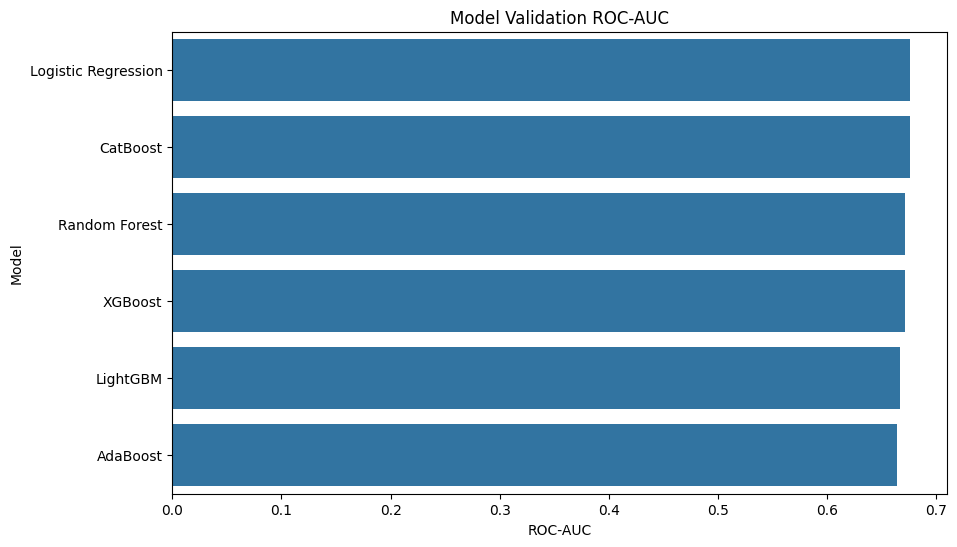

In [47]:
# ============================================================
# CELL 44 - MODEL SCORE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=score_df,
    x="Validation_ROC_AUC",
    y="Model"
)

plt.title("Model Validation ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")

plt.show()

In [48]:
# ============================================================
# CELL 45 - LR + RF ENSEMBLE
# ============================================================

lr_rf_valid_pred = (
    0.5 * lr_valid_pred
    +
    0.5 * rf_valid_pred
)

lr_rf_train_pred = (
    0.5 * lr_train_pred
    +
    0.5 * rf_train_pred
)

lr_rf_train_score = roc_auc_score(
    y_train,
    lr_rf_train_pred
)

lr_rf_valid_score = roc_auc_score(
    y_valid,
    lr_rf_valid_pred
)

print(
    f"LR + RF Train ROC-AUC: "
    f"{lr_rf_train_score:.4f}"
)

print(
    f"LR + RF Valid ROC-AUC: "
    f"{lr_rf_valid_score:.4f}"
)

LR + RF Train ROC-AUC: 0.7122
LR + RF Valid ROC-AUC: 0.6745


In [49]:
# ============================================================
# CELL 46 - ADVANCED ENSEMBLE
# ============================================================

ensemble_predictions = []
ensemble_weights = []

# Logistic Regression
ensemble_predictions.append(lr_valid_pred)
ensemble_weights.append(1.0)

# Random Forest
ensemble_predictions.append(rf_valid_pred)
ensemble_weights.append(1.0)

# AdaBoost
ensemble_predictions.append(ada_valid_pred)
ensemble_weights.append(1.0)

# XGBoost
if "xgb_valid_pred" in globals():
    ensemble_predictions.append(xgb_valid_pred)
    ensemble_weights.append(1.5)

# CatBoost
if "cat_valid_pred" in globals():
    ensemble_predictions.append(cat_valid_pred)
    ensemble_weights.append(1.5)

# LightGBM
if "lgbm_valid_pred" in globals():
    ensemble_predictions.append(lgbm_valid_pred)
    ensemble_weights.append(1.5)


# Weighted average
ensemble_valid_pred = np.zeros(
    len(y_valid)
)

total_weight = sum(
    ensemble_weights
)

for prediction, weight in zip(
    ensemble_predictions,
    ensemble_weights
):

    ensemble_valid_pred += (
        prediction * weight
    )

ensemble_valid_pred /= total_weight


ensemble_valid_score = roc_auc_score(
    y_valid,
    ensemble_valid_pred
)

print(
    f"Advanced Ensemble Valid ROC-AUC: "
    f"{ensemble_valid_score:.4f}"
)

Advanced Ensemble Valid ROC-AUC: 0.6744


In [50]:
# ============================================================
# CELL 47 - ENSEMBLE COMPARISON
# ============================================================

print("ENSEMBLE PERFORMANCE")
print("=" * 50)

print(
    f"Logistic Regression : {lr_valid_score:.4f}"
)

print(
    f"Random Forest       : {rf_valid_score:.4f}"
)

print(
    f"LR + RF             : {lr_rf_valid_score:.4f}"
)

print(
    f"Advanced Ensemble   : {ensemble_valid_score:.4f}"
)

ENSEMBLE PERFORMANCE
Logistic Regression : 0.6761
Random Forest       : 0.6713
LR + RF             : 0.6745
Advanced Ensemble   : 0.6744


In [51]:
# ============================================================
# CELL 48 -  RANDOM FOREST TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("Starting fast Random Forest tuning...")

rf_base = RandomForestClassifier(
    random_state=0,
    n_jobs=-1,
    class_weight="balanced"
)

rf_param_grid = {
    "n_estimators": [200],
    "max_depth": [8, 12, 16]
}

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=2,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(
    X_train,
    y_train
)

print("\n" + "=" * 60)
print("FAST GRID SEARCH COMPLETED")
print("=" * 60)

print("Best parameters:")
print(rf_grid.best_params_)

print(
    f"\nBest CV ROC-AUC: "
    f"{rf_grid.best_score_:.4f}"
)

Starting fast Random Forest tuning...
Fitting 2 folds for each of 3 candidates, totalling 6 fits

FAST GRID SEARCH COMPLETED
Best parameters:
{'max_depth': 8, 'n_estimators': 200}

Best CV ROC-AUC: 0.6699


In [52]:
# ============================================================
# CELL 49 - TUNED RANDOM FOREST
# ============================================================

tuned_rf = rf_grid.best_estimator_

tuned_rf_valid_pred = tuned_rf.predict_proba(
    X_valid
)[:, 1]

tuned_rf_valid_score = roc_auc_score(
    y_valid,
    tuned_rf_valid_pred
)

print(
    f"Tuned Random Forest Validation ROC-AUC: "
    f"{tuned_rf_valid_score:.4f}"
)

Tuned Random Forest Validation ROC-AUC: 0.6719


In [53]:
# ============================================================
# CELL 50 - LOGISTIC REGRESSION GRID SEARCH
# ============================================================

lr_base = LogisticRegression(
    random_state=0,
    max_iter=2000
)

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=lr_base,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(
    X_train_std,
    y_train
)

print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)

print(
    "\nBest CV ROC-AUC:",
    lr_grid.best_score_
)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Logistic Regression parameters:
{'C': 0.01, 'solver': 'lbfgs'}

Best CV ROC-AUC: 0.6747227826872119


In [54]:
# ============================================================
# CELL 51 - TUNED LOGISTIC REGRESSION
# ============================================================

tuned_lr = lr_grid.best_estimator_

tuned_lr_valid_pred = tuned_lr.predict_proba(
    X_valid_std
)[:, 1]

tuned_lr_valid_score = roc_auc_score(
    y_valid,
    tuned_lr_valid_pred
)

print(
    f"Tuned Logistic Regression "
    f"Validation ROC-AUC: "
    f"{tuned_lr_valid_score:.4f}"
)

Tuned Logistic Regression Validation ROC-AUC: 0.6763


In [55]:
# ============================================================
# CELL 52 - FINAL MODEL COMPARISON
# ============================================================

final_scores = {
    "Logistic Regression": lr_valid_score,
    "Tuned Logistic Regression": tuned_lr_valid_score,
    "Random Forest": rf_valid_score,
    "Tuned Random Forest": tuned_rf_valid_score,
    "AdaBoost": ada_valid_score,
    "LR + RF Ensemble": lr_rf_valid_score,
    "Advanced Ensemble": ensemble_valid_score
}

if "xgb_valid_score" in globals():
    final_scores["XGBoost"] = xgb_valid_score

if "cat_valid_score" in globals():
    final_scores["CatBoost"] = cat_valid_score

if "lgbm_valid_score" in globals():
    final_scores["LightGBM"] = lgbm_valid_score

final_score_df = pd.DataFrame(
    list(final_scores.items()),
    columns=[
        "Model",
        "Validation_ROC_AUC"
    ]
)

final_score_df = final_score_df.sort_values(
    "Validation_ROC_AUC",
    ascending=False
)

print(final_score_df.to_string(index=False))

                    Model  Validation_ROC_AUC
Tuned Logistic Regression            0.676261
      Logistic Regression            0.676096
                 CatBoost            0.675476
         LR + RF Ensemble            0.674455
        Advanced Ensemble            0.674448
      Tuned Random Forest            0.671886
            Random Forest            0.671291
                  XGBoost            0.670923
                 LightGBM            0.666995
                 AdaBoost            0.664056


In [56]:
# ============================================================
# CELL 53 - COMPETITION ENSEMBLE
# ============================================================

competition_valid_predictions = []
competition_weights = []


# Tuned Random Forest
competition_valid_predictions.append(
    tuned_rf_valid_pred
)

competition_weights.append(1.0)


# XGBoost
if "xgb_valid_pred" in globals():

    competition_valid_predictions.append(
        xgb_valid_pred
    )

    competition_weights.append(1.5)


# CatBoost
if "cat_valid_pred" in globals():

    competition_valid_predictions.append(
        cat_valid_pred
    )

    competition_weights.append(1.5)


# LightGBM
if "lgbm_valid_pred" in globals():

    competition_valid_predictions.append(
        lgbm_valid_pred
    )

    competition_weights.append(1.5)


competition_valid_pred = np.zeros(
    len(y_valid)
)

total_weight = sum(
    competition_weights
)

for prediction, weight in zip(
    competition_valid_predictions,
    competition_weights
):

    competition_valid_pred += (
        prediction * weight
    )

competition_valid_pred /= total_weight


competition_valid_score = roc_auc_score(
    y_valid,
    competition_valid_pred
)

print(
    "Competition Ensemble Validation "
    f"ROC-AUC: {competition_valid_score:.4f}"
)

Competition Ensemble Validation ROC-AUC: 0.6737


In [58]:
# ============================================================
# CELL 54 - TRAIN FINAL RANDOM FOREST
# ============================================================

print("Training final Random Forest on full training data...")

# Get the best parameters from GridSearch
best_rf_params = rf_grid.best_params_

print("Best Random Forest parameters:")
print(best_rf_params)

# ------------------------------------------------------------
# Final Random Forest
# ------------------------------------------------------------

final_rf = RandomForestClassifier(
    random_state=0,
    n_estimators=best_rf_params["n_estimators"],
    max_depth=best_rf_params["max_depth"],
    n_jobs=-1,
    class_weight="balanced"
)

# ------------------------------------------------------------
# Train on FULL training data
# ------------------------------------------------------------

final_rf.fit(
    X,
    y
)

print("\nFinal Random Forest trained successfully.")

Training final Random Forest on full training data...
Best Random Forest parameters:
{'max_depth': 8, 'n_estimators': 200}

Final Random Forest trained successfully.


In [59]:
# ============================================================
# CELL 55 - FINAL LOGISTIC REGRESSION
# ============================================================

final_sc = StandardScaler()

X_full_std = final_sc.fit_transform(X)

X_test_full_std = final_sc.transform(
    X_test
)

final_lr = LogisticRegression(
    C=lr_grid.best_params_["C"],
    solver=lr_grid.best_params_["solver"],
    random_state=0,
    max_iter=2000
)

final_lr.fit(
    X_full_std,
    y
)

print("Final Logistic Regression trained.")

Final Logistic Regression trained.


In [60]:
# ============================================================
# CELL 56 - FINAL XGBOOST
# ============================================================

if "XGBClassifier" in globals():

    final_xgb = XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=0,
        n_jobs=-1
    )

    final_xgb.fit(
        X,
        y
    )

    print("Final XGBoost trained.")

else:

    print("XGBoost unavailable.")

Final XGBoost trained.


In [61]:
# ============================================================
# CELL 57 - FINAL CATBOOST
# ============================================================

if "CatBoostClassifier" in globals():

    final_cat = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=0,
        verbose=False
    )

    final_cat.fit(
        X,
        y
    )

    print("Final CatBoost trained.")

else:

    print("CatBoost unavailable.")

Final CatBoost trained.


In [63]:
# ============================================================
# CELL 58 - FINAL LIGHTGBM
# ============================================================

print("Preparing final LightGBM data...")

# Copy full training and test data
X_full_lgb = X.copy()
X_test_full_lgb = X_test.copy()

# Make all column names strings
X_full_lgb.columns = X_full_lgb.columns.astype(str)
X_test_full_lgb.columns = X_test_full_lgb.columns.astype(str)

# Remove special characters from feature names
X_full_lgb.columns = (
    X_full_lgb.columns
    .str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
)

# Make test columns exactly the same
X_test_full_lgb.columns = X_full_lgb.columns

# Remove duplicate columns
X_full_lgb = X_full_lgb.loc[
    :,
    ~X_full_lgb.columns.duplicated()
]

X_test_full_lgb = X_test_full_lgb[
    X_full_lgb.columns
]

# Convert boolean columns to integers
for col in X_full_lgb.columns:
    if X_full_lgb[col].dtype == "bool":
        X_full_lgb[col] = X_full_lgb[col].astype(int)

for col in X_test_full_lgb.columns:
    if X_test_full_lgb[col].dtype == "bool":
        X_test_full_lgb[col] = X_test_full_lgb[col].astype(int)

# Fill any remaining missing values
X_full_lgb = X_full_lgb.fillna(
    X_full_lgb.median(numeric_only=True)
)

X_test_full_lgb = X_test_full_lgb.fillna(
    X_full_lgb.median(numeric_only=True)
)

print("LightGBM data prepared.")
print("Training shape:", X_full_lgb.shape)
print("Test shape:", X_test_full_lgb.shape)


# ------------------------------------------------------------
# Train final LightGBM
# ------------------------------------------------------------

if "LGBMClassifier" in globals():

    final_lgbm = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0,
        n_jobs=-1,
        verbosity=-1
    )

    final_lgbm.fit(
        X_full_lgb,
        y
    )

    print("\nFinal LightGBM trained successfully.")

else:

    print("LGBMClassifier is not available.")
    print("Please make sure LightGBM is installed.")

Preparing final LightGBM data...
LightGBM data prepared.
Training shape: (171202, 81)
Test shape: (61500, 81)

Final LightGBM trained successfully.


In [64]:
# ============================================================
# CELL 59 - TEST PREDICTIONS
# ============================================================

final_predictions = []
final_weights = []


# Random Forest
rf_test_pred = final_rf.predict_proba(
    X_test
)[:, 1]

final_predictions.append(
    rf_test_pred
)

final_weights.append(1.0)


# XGBoost
if "final_xgb" in globals():

    xgb_test_pred = final_xgb.predict_proba(
        X_test
    )[:, 1]

    final_predictions.append(
        xgb_test_pred
    )

    final_weights.append(1.5)


# CatBoost
if "final_cat" in globals():

    cat_test_pred = final_cat.predict_proba(
        X_test
    )[:, 1]

    final_predictions.append(
        cat_test_pred
    )

    final_weights.append(1.5)


# LightGBM
if "final_lgbm" in globals():

    lgbm_test_pred = final_lgbm.predict_proba(
        X_test
    )[:, 1]

    final_predictions.append(
        lgbm_test_pred
    )

    final_weights.append(1.5)


# Weighted ensemble
pred = np.zeros(
    len(X_test)
)

total_weight = sum(
    final_weights
)

for prediction, weight in zip(
    final_predictions,
    final_weights
):

    pred += (
        prediction * weight
    )

pred /= total_weight


print(
    "Number of predictions:",
    len(pred)
)

print("\nFirst 10 predictions:")
print(pred[:10])

print("\nPrediction statistics:")
print(pd.Series(pred).describe())

Number of predictions: 61500

First 10 predictions:
[0.09862317 0.18519148 0.22104103 0.13510082 0.20232298 0.09974066
 0.26916511 0.1959255  0.24708487 0.15729903]

Prediction statistics:
count    61500.000000
mean         0.153942
std          0.068282
min          0.009618
25%          0.106138
50%          0.144130
75%          0.184313
max          0.594606
dtype: float64


In [65]:
# ============================================================
# CELL 60 - CREATE SUBMISSION
# ============================================================

submission = sample_sub.copy()

submission["TARGET"] = pred

print("Submission preview:")
print(submission.head())

print("\nSubmission shape:")
print(submission.shape)

Submission preview:
   SK_ID_CURR    TARGET
0      171202  0.098623
1      171203  0.185191
2      171204  0.221041
3      171205  0.135101
4      171206  0.202323

Submission shape:
(61500, 2)


In [66]:
# ============================================================
# CELL 61 - SUBMISSION CHECK
# ============================================================

print("Submission columns:")
print(submission.columns.tolist())

print("\nExpected columns:")
print(sample_sub.columns.tolist())

print("\nMissing TARGET values:")
print(submission["TARGET"].isnull().sum())

print("\nTARGET statistics:")
print(submission["TARGET"].describe())

Submission columns:
['SK_ID_CURR', 'TARGET']

Expected columns:
['SK_ID_CURR', 'TARGET']

Missing TARGET values:
0

TARGET statistics:
count    61500.000000
mean         0.153942
std          0.068282
min          0.009618
25%          0.106138
50%          0.144130
75%          0.184313
max          0.594606
Name: TARGET, dtype: float64


In [67]:
# ============================================================
# CELL 62 - SAVE SUBMISSION
# ============================================================

output_dir = current_dir / "output"

output_dir.mkdir(
    exist_ok=True
)

output_file = (
    output_dir / "submission.csv"
)

submission.to_csv(
    output_file,
    index=False
)

print("Submission saved successfully:")
print(output_file)

Submission saved successfully:
d:\Personal\Study\Projects\Competition\output\submission.csv


In [68]:
# ============================================================
# CELL 63 - VERIFY SAVED SUBMISSION
# ============================================================

submission_check = pd.read_csv(
    output_file
)

print(
    "Submission shape:",
    submission_check.shape
)

print("\nSubmission head:")
print(submission_check.head())

print("\nSubmission tail:")
print(submission_check.tail())

Submission shape: (61500, 2)

Submission head:
   SK_ID_CURR    TARGET
0      171202  0.098623
1      171203  0.185191
2      171204  0.221041
3      171205  0.135101
4      171206  0.202323

Submission tail:
       SK_ID_CURR    TARGET
61495      232697  0.379755
61496      232698  0.117057
61497      232699  0.169753
61498      232700  0.240119
61499      232701  0.222339


In [69]:
# ============================================================
# CELL 64 - FINAL SUMMARY
# ============================================================

print("=" * 70)
print("COMPETITION MODEL SUMMARY")
print("=" * 70)

print(f"Training rows: {X.shape[0]}")
print(f"Test rows:     {X_test.shape[0]}")
print(f"Features:      {X.shape[1]}")

print("\nValidation Results:")
print("-" * 70)

print(
    f"Logistic Regression : {lr_valid_score:.4f}"
)

print(
    f"Random Forest       : {rf_valid_score:.4f}"
)

print(
    f"Tuned Random Forest : {tuned_rf_valid_score:.4f}"
)

print(
    f"AdaBoost            : {ada_valid_score:.4f}"
)

print(
    f"LR + RF Ensemble    : {lr_rf_valid_score:.4f}"
)

print(
    f"Advanced Ensemble   : {ensemble_valid_score:.4f}"
)

print(
    f"Competition Ensemble: {competition_valid_score:.4f}"
)

if "xgb_valid_score" in globals():

    print(
        f"XGBoost             : {xgb_valid_score:.4f}"
    )

if "cat_valid_score" in globals():

    print(
        f"CatBoost            : {cat_valid_score:.4f}"
    )

if "lgbm_valid_score" in globals():

    print(
        f"LightGBM            : {lgbm_valid_score:.4f}"
    )

print("\nSubmission:")
print(output_file)

print("=" * 70)

COMPETITION MODEL SUMMARY
Training rows: 171202
Test rows:     61500
Features:      81

Validation Results:
----------------------------------------------------------------------
Logistic Regression : 0.6761
Random Forest       : 0.6713
Tuned Random Forest : 0.6719
AdaBoost            : 0.6641
LR + RF Ensemble    : 0.6745
Advanced Ensemble   : 0.6744
Competition Ensemble: 0.6737
XGBoost             : 0.6709
CatBoost            : 0.6755
LightGBM            : 0.6670

Submission:
d:\Personal\Study\Projects\Competition\output\submission.csv


In [70]:
# ============================================================
# CELL 65 - ZIP NOTEBOOK
# ============================================================

import zipfile

notebook_filename = "tutorial.ipynb"
zip_filename = "tutorial.zip"

notebook_path = (
    current_dir / notebook_filename
)

zip_output_path = (
    current_dir / zip_filename
)

if notebook_path.exists():

    with zipfile.ZipFile(
        zip_output_path,
        "w",
        zipfile.ZIP_DEFLATED
    ) as zipf:

        zipf.write(
            notebook_path,
            arcname=notebook_filename
        )

    print(
        f"Successfully created: "
        f"{zip_output_path}"
    )

else:

    print(
        f"Could not find "
        f"'{notebook_filename}' "
        f"in {current_dir}."
    )

Successfully created: d:\Personal\Study\Projects\Competition\tutorial.zip
